# Barcode Decode: Native vs SAA vs SAA+IBP

Run `imaging/sr/sweep_sr_barcodes.py` first to generate the SR output images in `sr_output/`.

This notebook:
1. Lets you define ROIs for the three main barcodes (fill in the ROI cell)
2. Decodes each barcode with zxing-cpp for all three SR methods
3. Plots decode confidence vs barcode pitch for each method

**Requires the `sr310` conda environment** (`conda activate sr310`), which has Python 3.10
and a pre-built `zxing-cpp` wheel.

In [20]:
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
import zxingcpp

NB_DIR = os.path.dirname(os.path.abspath("barcode_decode.ipynb"))
SR_DIR = os.path.join(NB_DIR, "sr_output")

# ── Load all three SR output images ───────────────────────────────────────────
images = {
    "Native-2x": np.array(Image.open(os.path.join(SR_DIR, "native_2x.png"))),
    "SAA":       np.array(Image.open(os.path.join(SR_DIR, "SAA.png"))),
    "SAA+IBP":   np.array(Image.open(os.path.join(SR_DIR, "SAA_IBP.png"))),
}

for name, img in images.items():
    print(f"{name:10s}  shape={img.shape}  dtype={img.dtype}  "
          f"min={img.min()}  max={img.max()}")

Native-2x   shape=(1536, 2048)  dtype=uint8  min=4  max=206
SAA         shape=(1536, 2048)  dtype=uint8  min=5  max=200
SAA+IBP     shape=(1536, 2048)  dtype=uint8  min=0  max=255


## ROI Definition

Use the full-image display below to identify pixel coordinates for each barcode.
All coordinates are in **HR image space** (same for all three SR output images).

Each ROI is `(row_start, row_end, col_start, col_end)`.
`pitch_mil` is the barcode's bar pitch in mils (thousandths of an inch).

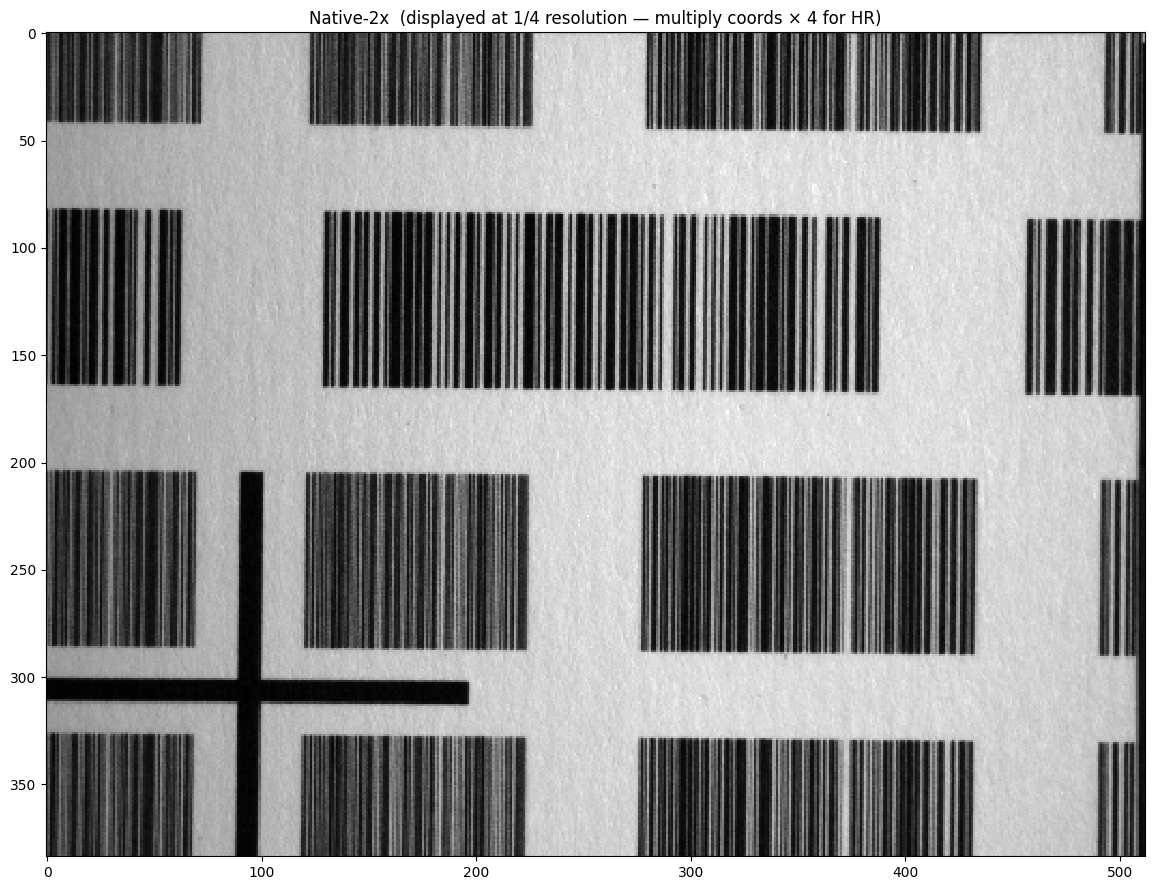

In [21]:
# ── Quick full-image display to help locate barcodes ──────────────────────────
# Use this to read off approximate row/col coordinates.
# (Down-sampled 4× for display; multiply coordinates shown in imshow by 4 to
#  get HR pixel coordinates.)

ref = images["Native-2x"]
fig, ax = plt.subplots(figsize=(12, 9))
ax.imshow(ref[::4, ::4], cmap="gray", interpolation="nearest")
ax.set_title("Native-2x  (displayed at 1/4 resolution — multiply coords × 4 for HR)")
plt.tight_layout()
plt.show()

In [22]:
# ══════════════════════════════════════════════════════════════════════════════
# EDIT THIS CELL — fill in your ROIs and barcode pitches
# ══════════════════════════════════════════════════════════════════════════════
#
# ROI format: (row_start, row_end, col_start, col_end)  — HR pixel coordinates
# pitch_mil : barcode bar pitch in mils (1 mil = 25.4 µm)
#
# Example (replace with your actual values):
#   {"label": "2 mil",  "roi": (200, 400, 100, 500),  "pitch_mil": 2}
#   {"label": "4 mil",  "roi": (200, 400, 600, 1000), "pitch_mil": 4}
#   {"label": "6 mil",  "roi": (200, 400, 1100, 1600),"pitch_mil": 6}

BARCODES = [
    {"label": "Barcode A",  "roi": (200*4, 290*4, 105*4, 240*4),  "pitch_mil": 2},
    {"label": "Barcode B",  "roi": (200*4, 295*4, 270*4, 440*4),  "pitch_mil": 3},
    {"label": "Barcode C",  "roi": (75*4, 180*4, 115*4, 400*4),  "pitch_mil": 5},
]

# Verify ROIs are filled in before proceeding
for bc in BARCODES:
    assert None not in bc["roi"],      f"Fill in ROI for {bc['label']}"
    assert bc["pitch_mil"] is not None, f"Fill in pitch_mil for {bc['label']}"

print("ROIs defined:")
for bc in BARCODES:
    r0, r1, c0, c1 = bc["roi"]
    print(f"  {bc['label']:12s}  pitch={bc['pitch_mil']} mil  "
          f"rows [{r0}:{r1}]  cols [{c0}:{c1}]  "
          f"size=({r1-r0}×{c1-c0} px)")

ROIs defined:
  Barcode A     pitch=2 mil  rows [800:1160]  cols [420:960]  size=(360×540 px)
  Barcode B     pitch=3 mil  rows [800:1180]  cols [1080:1760]  size=(380×680 px)
  Barcode C     pitch=5 mil  rows [300:720]  cols [460:1600]  size=(420×1140 px)


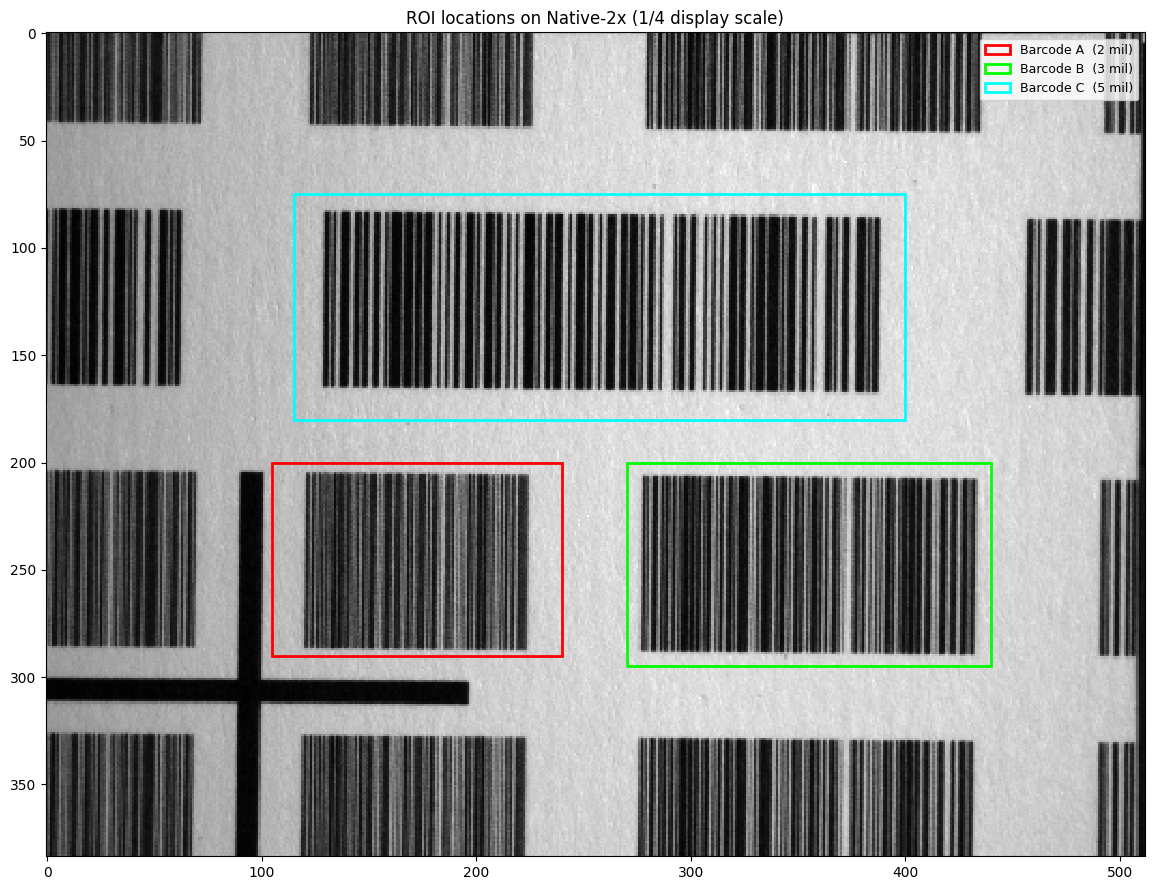

In [23]:
# ── Overlay ROI boxes on the full image ───────────────────────────────────────
# Confirms the boxes are placed correctly before decoding.

COLORS_METHOD = {"Native-2x": "C0", "SAA": "C2", "SAA+IBP": "C3"}
COLORS_ROI    = ["red", "lime", "cyan"]

fig, ax = plt.subplots(figsize=(12, 9))
ax.imshow(images["Native-2x"][::4, ::4], cmap="gray", interpolation="nearest")

for bc, color in zip(BARCODES, COLORS_ROI):
    r0, r1, c0, c1 = bc["roi"]
    rect = patches.Rectangle(
        (c0 / 4, r0 / 4), (c1 - c0) / 4, (r1 - r0) / 4,
        linewidth=2, edgecolor=color, facecolor="none",
        label=f"{bc['label']}  ({bc['pitch_mil']} mil)",
    )
    ax.add_patch(rect)

ax.legend(loc="upper right", fontsize=9)
ax.set_title("ROI locations on Native-2x (1/4 display scale)")
plt.tight_layout()
plt.show()

## Decode Function

Confidence is estimated by attempting to decode `N_TRIALS` slightly-shifted crops
of each ROI and reporting the fraction that succeed (0–1). This gives a meaningful
score when the barcode is near the resolution limit and decodability is sensitive
to exact sub-pixel alignment.

In [24]:
N_TRIALS   = 25   # number of jitter trials per ROI
MAX_JITTER = 8    # max pixel shift in each direction (HR pixels)
RNG        = np.random.default_rng(42)


def decode_confidence(img_gray, roi, n_trials=N_TRIALS, max_jitter=MAX_JITTER):
    """
    Decode a barcode ROI using zxing-cpp, with jitter-based confidence estimation.

    Parameters
    ----------
    img_gray  : 2-D uint8 numpy array (full HR image)
    roi       : (r0, r1, c0, c1) in HR pixel coordinates
    n_trials  : number of random jitter trials
    max_jitter: max pixel offset per direction (HR pixels)

    Returns
    -------
    text       : str or None  — decoded text from the centre crop (None if failed)
    confidence : float 0–1   — fraction of jitter trials that decoded successfully
    """
    r0, r1, c0, c1 = roi
    H, W = img_gray.shape

    # ── Centre-crop decode ────────────────────────────────────────────────────
    centre_crop = img_gray[r0:r1, c0:c1]
    centre_res  = zxingcpp.read_barcodes(centre_crop)
    text = centre_res[0].text if centre_res else None

    # ── Jitter trials ─────────────────────────────────────────────────────────
    successes = 0
    for _ in range(n_trials):
        dr = int(RNG.integers(-max_jitter, max_jitter + 1))
        dc = int(RNG.integers(-max_jitter, max_jitter + 1))

        rr0 = max(0, r0 + dr);  rr1 = min(H, r1 + dr)
        rc0 = max(0, c0 + dc);  rc1 = min(W, c1 + dc)
        crop = img_gray[rr0:rr1, rc0:rc1]
        if crop.size == 0:
            continue
        if zxingcpp.read_barcodes(crop):
            successes += 1

    return text, successes / n_trials


def crop_roi(img_gray, roi):
    r0, r1, c0, c1 = roi
    return img_gray[r0:r1, c0:c1]


print(f"decode_confidence ready  (N_TRIALS={N_TRIALS}, max_jitter={MAX_JITTER} px)")

decode_confidence ready  (N_TRIALS=25, max_jitter=8 px)


## Run Decoding on All Barcodes × Methods

In [25]:
METHOD_NAMES = ["Native-2x", "SAA", "SAA+IBP"]

# results[method] = list of dicts, one per barcode
results = {m: [] for m in METHOD_NAMES}

for method in METHOD_NAMES:
    img = images[method]
    print(f"\n{'─'*50}")
    print(f"  {method}")
    print(f"{'─'*50}")
    for bc in BARCODES:
        text, conf = decode_confidence(img, bc["roi"])
        results[method].append({
            "label":      bc["label"],
            "pitch_mil":  bc["pitch_mil"],
            "text":       text,
            "confidence": conf,
        })
        status = f"'{text}'" if text else "FAIL"
        print(f"  {bc['label']:12s}  {bc['pitch_mil']} mil  "
              f"conf={conf:.2f}  → {status}")


──────────────────────────────────────────────────
  Native-2x
──────────────────────────────────────────────────
  Barcode A     2 mil  conf=0.00  → FAIL
  Barcode B     3 mil  conf=0.00  → FAIL
  Barcode C     5 mil  conf=1.00  → '005.0r-018c+015'

──────────────────────────────────────────────────
  SAA
──────────────────────────────────────────────────
  Barcode A     2 mil  conf=0.00  → FAIL
  Barcode B     3 mil  conf=0.00  → FAIL
  Barcode C     5 mil  conf=0.00  → FAIL

──────────────────────────────────────────────────
  SAA+IBP
──────────────────────────────────────────────────
  Barcode A     2 mil  conf=0.00  → FAIL
  Barcode B     3 mil  conf=0.00  → FAIL
  Barcode C     5 mil  conf=1.00  → '005.0r-018c+015'


## Visual Comparison: Cropped Barcodes

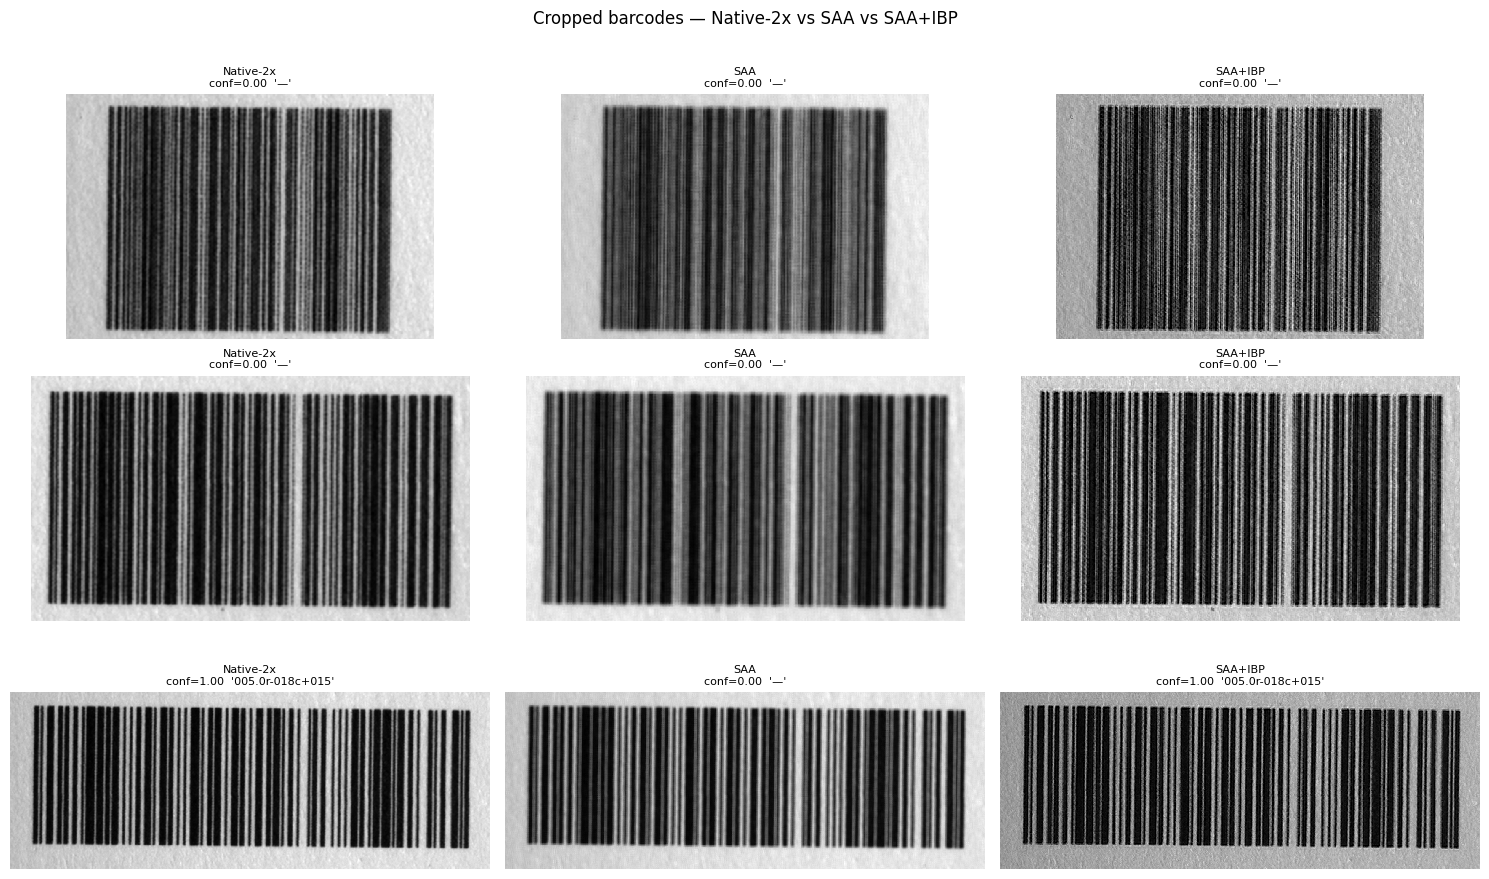

In [26]:
n_bc  = len(BARCODES)
n_met = len(METHOD_NAMES)

fig, axes = plt.subplots(n_bc, n_met, figsize=(5 * n_met, 3 * n_bc),
                          squeeze=False)

for row, bc in enumerate(BARCODES):
    for col, method in enumerate(METHOD_NAMES):
        crop = crop_roi(images[method], bc["roi"])
        ax   = axes[row][col]
        ax.imshow(crop, cmap="gray", interpolation="nearest")

        res  = results[method][row]
        conf = res["confidence"]
        text = res["text"] or "—"
        ax.set_title(f"{method}\nconf={conf:.2f}  '{text}'", fontsize=8)
        ax.axis("off")

    axes[row][0].set_ylabel(
        f"{bc['label']}\n{bc['pitch_mil']} mil", fontsize=9,
        rotation=0, ha="right", va="center", labelpad=5,
    )

plt.suptitle("Cropped barcodes — Native-2x vs SAA vs SAA+IBP", fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

## Decode Confidence vs Barcode Pitch

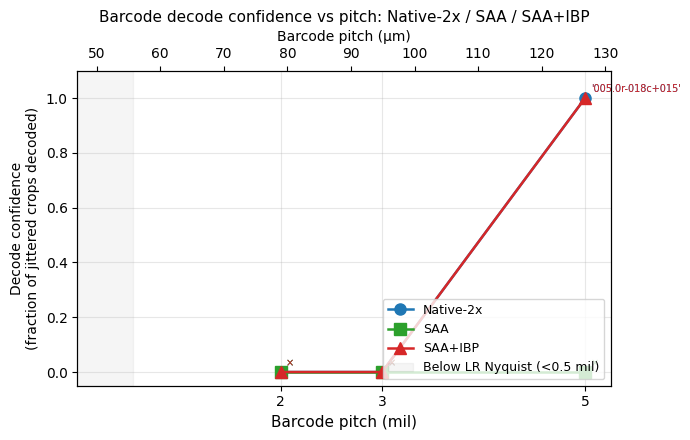

Saved decode_confidence_vs_pitch.png


In [27]:
PIXEL_PITCH_UM  = 3.45   # sensor pixel pitch (µm)
MIL_TO_UM       = 25.4   # 1 mil = 25.4 µm
HR_PITCH_UM     = PIXEL_PITCH_UM   # HR pixel = 1 sensor pixel after 2× SR

pitches_mil = sorted(set(bc["pitch_mil"] for bc in BARCODES))

fig, ax = plt.subplots(figsize=(7, 4.5))

markers = {"Native-2x": "o", "SAA": "s", "SAA+IBP": "^"}

for method in METHOD_NAMES:
    x_vals = [r["pitch_mil"]  for r in results[method]]
    y_vals = [r["confidence"] for r in results[method]]
    # Sort by pitch
    pairs  = sorted(zip(x_vals, y_vals))
    x_vals, y_vals = zip(*pairs)

    ax.plot(x_vals, y_vals,
            color=COLORS_METHOD[method],
            marker=markers[method],
            markersize=8,
            linewidth=1.8,
            label=method)

    # Annotate each point with decoded text (or "×" for fail)
    for xi, yi, res in sorted(
        zip(x_vals, y_vals, results[method]),
        key=lambda t: t[0]
    ):
        label_txt = f"'{res['text']}'" if res['text'] else "×"
        ax.annotate(label_txt, (xi, yi),
                    textcoords="offset points", xytext=(4, 4),
                    fontsize=7, color=COLORS_METHOD[method])

# Add secondary x-axis showing pitch in µm
ax2 = ax.twiny()
ax2.set_xlim(
    np.array(ax.get_xlim()) * MIL_TO_UM
)
ax2.set_xlabel("Barcode pitch (µm)", fontsize=10)

# Shaded region below sensor Nyquist
nyquist_lr_mil = (PIXEL_PITCH_UM * 2 * 2) / MIL_TO_UM  # 2 LR pixels per period → min pitch
ax.axvspan(0, nyquist_lr_mil, alpha=0.08, color="gray",
           label=f"Below LR Nyquist (<{nyquist_lr_mil:.1f} mil)")

ax.set_xlabel("Barcode pitch (mil)", fontsize=11)
ax.set_ylabel("Decode confidence\n(fraction of jittered crops decoded)", fontsize=10)
ax.set_title("Barcode decode confidence vs pitch: Native-2x / SAA / SAA+IBP", fontsize=11)
ax.set_ylim(-0.05, 1.10)
ax.set_xlim(left=0)
ax.set_xticks(pitches_mil)
ax.yaxis.set_major_locator(plt.MultipleLocator(0.2))
ax.grid(True, alpha=0.3)
ax.legend(fontsize=9, loc="lower right")

plt.tight_layout()
plt.savefig(os.path.join(NB_DIR, "decode_confidence_vs_pitch.png"),
            dpi=150, bbox_inches="tight")
plt.show()
print("Saved decode_confidence_vs_pitch.png")